In [1]:
import pandas as pd
import os

In [2]:
import statsmodels.stats.multitest as multi
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
def fdr(df,p):
    #calculate benjamin-hochberg fdr
    df["p"]=pd.to_numeric(df["p"].squeeze())
    probabilities = np.array(df["p"].squeeze())
    report = multi.multipletests(probabilities,
                alpha=0.05,
                method="fdr_bh",
                is_sorted=False,
            )
    discoveries = report[1]
    df["fdr"]=discoveries
    df["fdr"]=pd.to_numeric(df["fdr"].squeeze())
    df["-log10(fdr)"]=-np.log10(df["fdr"])
    
    return(df)


### get genetic correlation data

In [5]:
ldsc_dir="../data/correlation/"
files=[x for x in os.listdir(ldsc_dir) if "log" in x]

data=[]

for x in files:
    with open(ldsc_dir+x) as f:
        first_line = f.readline()
        for i,line in enumerate(f):
            if "testosterone.sumstats" in line:
                if len(line.strip().split())==12:
                    data.append(line.strip().split())

headr=[]
with open(ldsc_dir+x) as f:
    first_line = f.readline()
    for i,line in enumerate(f):
        if "p1" in line:
            headr.append(line.strip().split())

df=pd.DataFrame(data)
df.columns=headr
df["files"]=files

In [6]:
df=fdr(df,"p")

In [7]:
df["Reference"]=df["files"].squeeze().str.split(".").str[2]

In [8]:
df

,p1,p2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se,files,fdr,-log10(fdr),Reference
0,eur.testosterone.sumstats.gz,afr.testosterone.sumstats.gz,0.1091,0.0979,1.1149,0.2649,0.1125,0.0397,1.025,0.0087,0.0095,0.0045,eur.afr.afr.ref.corr.log,0.26490,0.576918,afr
1,afr.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.3686,0.2112,1.7452,0.0809,0.1074,0.0686,1.0355,0.0098,0.0035,0.0038,afr.his.afr.ref.corr.log,0.09708,1.012870,afr
2,eur.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.5103,0.1524,3.3479,0.0008,0.0839,0.029,1.0287,0.0079,0.0165,0.0058,eur.his.his.ref.corr.log,0.00240,2.619789,his
3,eur.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.6014,0.1781,3.377,0.0007,0.0822,0.0345,1.0336,0.0083,0.0141,0.0058,eur.his.eur.ref.corr.log,0.00240,2.619789,eur
4,eur.testosterone.sumstats.gz,afr.testosterone.sumstats.gz,0.1922,0.0704,2.7312,0.0063,0.048,0.0144,1.0316,0.0072,0.007,0.0038,eur.afr.eur.ref.corr.log,0.01260,1.899629,eur
5,afr.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.2817,0.151,1.8648,0.0622,0.0804,0.029,1.0295,0.0079,0.0032,0.0035,afr.his.his.ref.corr.log,0.09330,1.030118,his


In [9]:
df.to_csv("genetic.correlation.csv",index=None)

In [12]:
df[["p1","p2","Reference","rg","p"]]

,p1,p2,Reference,rg,p
0,eur.testosterone.sumstats.gz,his.testosterone.sumstats.gz,his,0.5103,0.0008
1,eur.testosterone.sumstats.gz,afr.testosterone.sumstats.gz,afr,0.1091,0.2649
2,eur.testosterone.sumstats.gz,his.testosterone.sumstats.gz,eur,0.6014,0.0007
3,afr.testosterone.sumstats.gz,his.testosterone.sumstats.gz,his,0.2817,0.0622
4,eur.testosterone.sumstats.gz,afr.testosterone.sumstats.gz,eur,0.1922,0.0063
5,afr.testosterone.sumstats.gz,his.testosterone.sumstats.gz,afr,0.3686,0.0809


In [53]:
pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9,10,11
0,eur.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.5103,0.1524,3.3479,0.0008,0.0839,0.029,1.0287,0.0079,0.0165,0.0058
1,eur.testosterone.sumstats.gz,afr.testosterone.sumstats.gz,0.1091,0.0979,1.1149,0.2649,0.1125,0.0397,1.025,0.0087,0.0095,0.0045
2,eur.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.6014,0.1781,3.377,0.0007,0.0822,0.0345,1.0336,0.0083,0.0141,0.0058
3,afr.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.2817,0.151,1.8648,0.0622,0.0804,0.029,1.0295,0.0079,0.0032,0.0035
4,eur.testosterone.sumstats.gz,afr.testosterone.sumstats.gz,0.1922,0.0704,2.7312,0.0063,0.048,0.0144,1.0316,0.0072,0.007,0.0038
5,afr.testosterone.sumstats.gz,his.testosterone.sumstats.gz,0.3686,0.2112,1.7452,0.0809,0.1074,0.0686,1.0355,0.0098,0.0035,0.0038


In [35]:
df["p1"].squeeze()

0    eur.testosterone.sumstats.gz
1    eur.testosterone.sumstats.gz
2    eur.testosterone.sumstats.gz
3    afr.testosterone.sumstats.gz
4    eur.testosterone.sumstats.gz
5    afr.testosterone.sumstats.gz
Name: (p1,), dtype: object

In [22]:
df["h2_obs"]

,h2_obs
0,0.0839
1,0.1125
2,0.0822
3,0.0804
4,0.048
5,0.1074


In [8]:
df=pd.DataFrame(data)

In [9]:
df.columns=headr

In [10]:
df.to_csv("corr.csv")

In [11]:
df=pd.read_csv("corr.csv")

In [12]:
df=fdr(df)

In [13]:
df["p1_category"]="ethnic"
df["p2_category"]="ethnic"

In [14]:
df[["p1_category","p1","p2_category","p2","rg","p","q"]].to_csv("input_rg.txt",index=None,sep="\t")

In [15]:
trait=pd.DataFrame({"CATEGORY":"ethnic","TRAIT":df["p1"].tolist(),"COLOR":"#4C72AE"})

In [16]:
trait.to_csv("traitlist.txt",index=None,sep="\t")

In [17]:
df["-log10fdr"]=-np.log10(df["q"])

In [18]:
df=df.sort_values(by="p1")

In [20]:
df["p1"]=df["p1"].str.split(".").str[0]
df["p2"]=df["p2"].str.split(".").str[0]

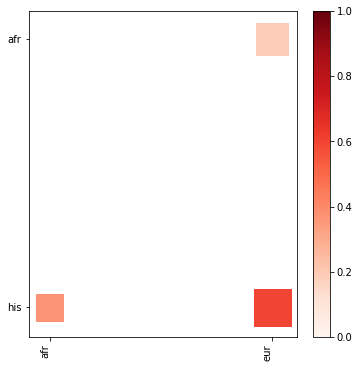

In [21]:
#Plot

def heatmap(x, y, size,color):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Mapping from column names to integer coordinates
    x_labels = [v for v in x.unique()]
    y_labels = [v for v in y.unique()]
    x_to_num = {p[1]:p[0] for p in enumerate(x_labels)} 
    y_to_num = {p[1]:p[0] for p in enumerate(y_labels)} 
    
    size_scale = 500
    plt.scatter(
        x=x.map(x_to_num), # Use mapping for x
        y=y.map(y_to_num), # Use mapping for y
        s=size * size_scale, 
        c=color,
        marker="s",
        cmap="Reds", vmin=0, vmax=1# Vector of square sizes, proportional to size parameter
    )
    
    # Show column labels on the axes
    ax.set_xticks([x_to_num[v] for v in x_labels])
    ax.set_xticklabels(x_labels, rotation=45, horizontalalignment='right')
    ax.set_yticks([y_to_num[v] for v in y_labels])
    ax.set_yticklabels(y_labels)
    plt.colorbar()
    
    plt.xticks(rotation=90)
    
    
heatmap(
    x=df['p1'],
    y=df['p2'],
    size=df['-log10fdr'],
    color=df['rg'],
)

plt.savefig("ethnic.corrplot.pdf")


In [23]:
df_size=df.copy()

In [31]:
df_size["-log10fdr"][2]=1
df_size["-log10fdr"][1]=2
df_size["-log10fdr"][0]=3

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the i

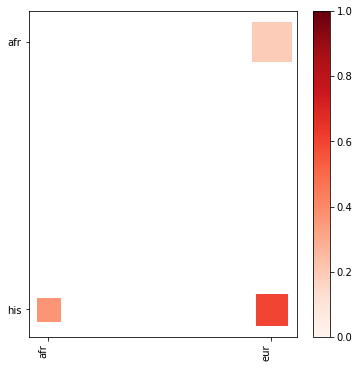

In [32]:
#Plot

def heatmap(x, y, size,color):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Mapping from column names to integer coordinates
    x_labels = [v for v in x.unique()]
    y_labels = [v for v in y.unique()]
    x_to_num = {p[1]:p[0] for p in enumerate(x_labels)} 
    y_to_num = {p[1]:p[0] for p in enumerate(y_labels)} 
    
    size_scale = 500
    plt.scatter(
        x=x.map(x_to_num), # Use mapping for x
        y=y.map(y_to_num), # Use mapping for y
        s=size * size_scale, 
        c=color,
        marker="s",
        cmap="Reds", vmin=0, vmax=1# Vector of square sizes, proportional to size parameter
    )
    
    # Show column labels on the axes
    ax.set_xticks([x_to_num[v] for v in x_labels])
    ax.set_xticklabels(x_labels, rotation=45, horizontalalignment='right')
    ax.set_yticks([y_to_num[v] for v in y_labels])
    ax.set_yticklabels(y_labels)
    plt.colorbar()
    
    plt.xticks(rotation=90)
    
    
heatmap(
    x=df_size['p1'],
    y=df_size['p2'],
    size=df_size['-log10fdr'],
    color=df_size['rg'],
)

plt.savefig("ethnic.corrplot.size.pdf")


In [30]:
df["-log10fdr"]

2    1.477556
0    2.024568
1    2.677781
Name: -log10fdr, dtype: float64